In [7]:
import sys
!{sys.executable} -m pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [8]:
# Import library yang kalian butuhkan
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

## Import Library

Script di atas mengimpor seluruh library yang dibutuhkan dalam pipeline pengolahan citra dan klasifikasi. Library `os` digunakan untuk navigasi sistem file, `cv2` (OpenCV) untuk membaca dan memproses citra, serta `matplotlib.pyplot` dan `seaborn` untuk keperluan visualisasi. `numpy` dan `pandas` digunakan untuk operasi numerik dan pengelolaan data tabular. Dari `sklearn`, diimpor fungsi pembagian data (`train_test_split`), tiga model klasifikasi (`RandomForestClassifier`, `SVC`, `KNeighborsClassifier`), serta berbagai metrik evaluasi seperti akurasi, precision, recall, F1-score, confusion matrix, dan classification report. Library `skimage.feature` digunakan untuk menghitung matriks GLCM dan mengekstrak propertinya, sedangkan `scipy.stats` menyediakan fungsi `entropy` untuk menghitung nilai entropi dari distribusi tekstur. Selain itu, `glob` dan `random` diimpor untuk keperluan pengelolaan path file dan pengacakan data.  

## Data Loading

Buat struktur folder dataset sebagai berikut:
```
.
└──dataset
    ├── label1
	├── image1.jpg
	├── image2.jpg
	└── image3.jpg
    ├── label2
    └── label3
    └── dst...
```

In [9]:
data = []
labels = []
file_name = []

for sub_folder in os.listdir("dataset"):
    sub_folder_files = os.listdir(os.path.join("dataset", sub_folder))
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join("dataset", sub_folder, filename)
        img = cv.imread(img_path)

        if img is None:
            continue

        data.append(img)
        labels.append(sub_folder)
        file_name.append(f"{sub_folder}_{i+1}.jpg")

print(f"Total data: {len(data)}")
print(f"Kelas: {sorted(set(labels))}")

Total data: 200
Kelas: ['Grape_black_rot_100', 'daun_sehat_100']


## Data Loading

Script diatas memuat seluruh data citra dari direktori `dataset` yang terstruktur dalam subfolder berlabel. Tiga list kosong diinisialisasi untuk menampung gambar (`data`), nama kelas (`labels`), dan nama file (`file_name`). Proses iterasi dilakukan dua lapis — lapisan pertama menelusuri setiap subfolder sebagai representasi kelas, lapisan kedua membaca satu per satu file gambar di dalamnya menggunakan `cv.imread`. Setiap gambar yang berhasil dibaca disimpan ke list `data`, nama subfoldernya dicatat sebagai label, dan nama file terformat disimpan ke `file_name`. Gambar yang gagal dibaca (bernilai `None`) dilewati agar tidak mengganggu proses selanjutnya dan menampilkan total jumlah data menggunakan `len(data)`, sedangkan baris kedua menampilkan daftar kelas unik yang ada dalam dataset dengan mengambil nilai unik dari list `labels` dan mengurutkannya secara alfabetis menggunakan `sorted(set(labels))`.

## Definisi Fungsi Preprocessing

Script di bawah ini mendefinisikan empat fungsi preprocessing yang akan diterapkan secara berurutan pada setiap citra. Fungsi `gray` meresize gambar ke ukuran `(256, 256)` lalu mengonversinya ke grayscale menggunakan `cv.COLOR_BGR2GRAY`, dengan output bertipe `uint8`. Fungsi `median` menerapkan median blur dengan kernel berukuran 5 untuk meredam noise pada gambar, dan dapat menerima input berupa path file string maupun array gambar langsung. Fungsi `histogram_equalization` meratakan distribusi intensitas piksel menggunakan `cv.equalizeHist` untuk meningkatkan kontras citra grayscale. Ketiga fungsi tersebut digabungkan dalam fungsi `prepro` sebagai satu pipeline yang berjalan berurutan: grayscale → median filter → histogram equalization. Fungsi `percobaan2` berfungsi sebagai pembungkus `prepro` yang menerima gambar dan mengembalikan hasil akhir preprocessing dan menerapkan pipeline preprocessing ke seluruh data menggunakan list comprehension, menghasilkan list `dataPreprocessed` yang berisi semua citra yang telah diproses. Selanjutnya, untuk setiap kelas unik, ditampilkan preview 18 gambar pertama dalam grid 3×6 menggunakan `plt.subplots`. Setiap gambar ditampilkan dalam colormap grayscale tanpa sumbu, dengan judul figure yang disesuaikan dengan nama label kelas yang sedang ditampilkan. Proses ini bertujuan untuk memverifikasi secara visual bahwa hasil preprocessing sudah sesuai sebelum dilanjutkan ke tahap ekstraksi fitur.

In [ ]:
TARGET_SIZE = (256, 256)

def gray(image, target_size=TARGET_SIZE):
    resized = cv.resize(image, target_size)
    if len(resized.shape) == 3:
        gray = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
    else:
        gray = resized
    return gray.astype(np.uint8)


def median(image_input, kernel_size=5):
    if isinstance(image_input, str):
        img = cv.imread(image_input, cv.IMREAD_GRAYSCALE)
    else:
        img = image_input.copy()

    pad_size = kernel_size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img)
    height, width = img.shape

    for i in range(height):
        for j in range(width):
            region = padded[i:i+kernel_size, j:j+kernel_size]
            counts, _ = np.histogram(region, bins=256, range=(0, 256))
            cdf = np.cumsum(counts)
            half = (region.size + 1) // 2
            canvas[i, j] = np.argmin(cdf < half)

    return canvas.astype(np.uint8)


def histogram_equalization(image_input):
    if isinstance(image_input, str):
        img = cv.imread(image_input, cv.IMREAD_GRAYSCALE)
    else:
        img = image_input.copy()

    L = 256
    counts, _ = np.histogram(img, bins=L, range=(0, L)) 
    cdf = np.cumsum(counts)

    cdf_min = np.min(cdf[cdf > 0])
    total_pixel = np.sum(counts)

    mapping = np.round((cdf - cdf_min) / (total_pixel - cdf_min) * (L - 1))
    mapping = np.clip(mapping, 0, L - 1)

    equalized_result = mapping[img].astype(np.uint8)
    return equalized_result

In [11]:
def prepro(image):
    img = gray(image)
    img = median(img)
    img = histogram_equalization(img)
    
    return img

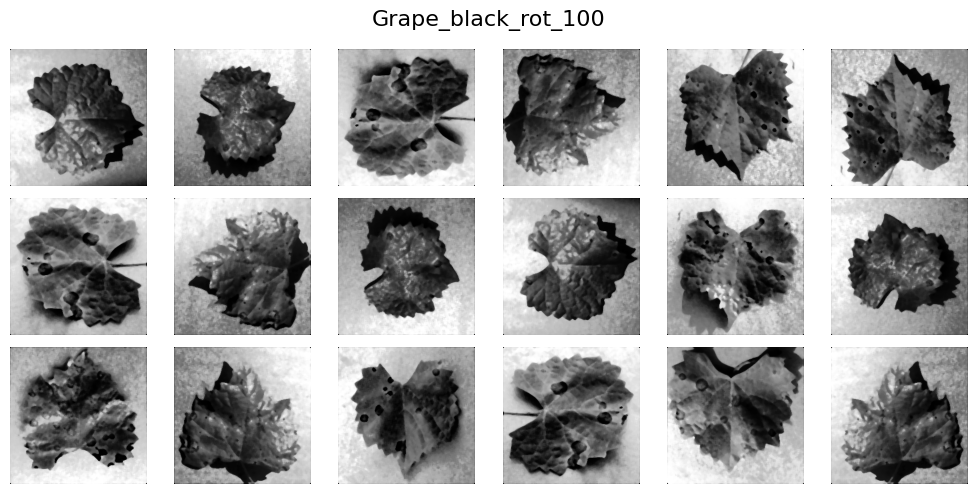

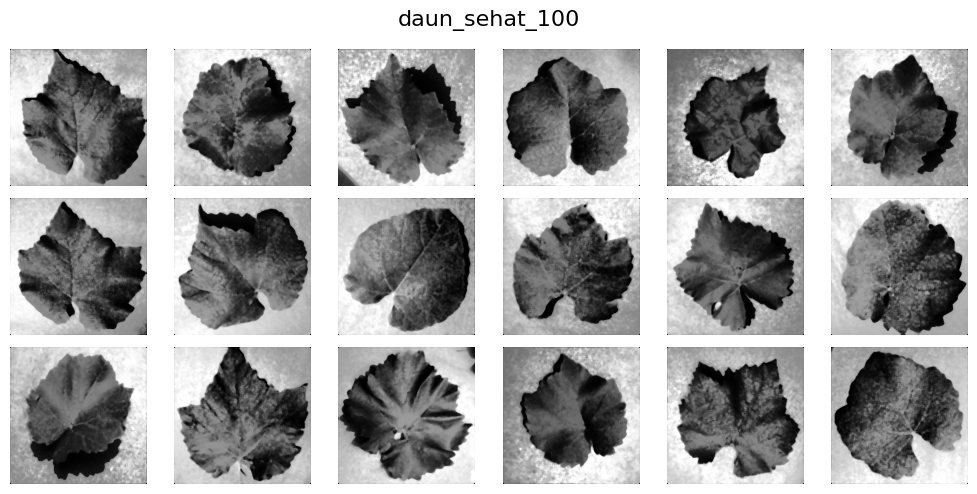

In [12]:
def percobaan2(img):
    hasil = prepro(img)
    return hasil

dataPreprocessed = [percobaan2(img) for img in data]

unique_labels = sorted(set(labels))

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels) if l == label]

    fig, axs = plt.subplots(3, 6, figsize=(10, 5))
    fig.suptitle(f'{label}', fontsize=16)

    for k in range(min(18, len(idxs))):
        row = k // 6
        col = k % 6
        ax  = axs[row][col]

        ax.imshow(dataPreprocessed[idxs[k]], cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

### Feature Extraction

In [13]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")
    
    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

In [14]:
def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

## Definisi Fungsi Ekstraksi Fitur GLCM

Script di atas mendefinisikan delapan fungsi untuk keperluan ekstraksi fitur tekstur berbasis GLCM. Fungsi `glcm` membangun matriks Gray-Level Co-occurrence Matrix dari sebuah citra pada sudut yang ditentukan (0°, 45°, 90°, atau 135°) — sudut dikonversi ke radian, dan matriks dihitung dengan jarak 1, 256 level intensitas, bersifat simetris, dan dinormalisasi. Fungsi `correlation`, `dissimilarity`, `homogenity`, dan `contrast` masing-masing mengekstrak properti tekstur yang bersesuaian dari matriks GLCM menggunakan `graycoprops`. Fungsi `ASM` mengekstrak Angular Second Moment yang merepresentasikan keseragaman tekstur, fungsi `energy` mengekstrak nilai energy (akar dari ASM), dan fungsi `entropyGlcm` menghitung entropi dengan meratakan matriks GLCM menjadi array satu dimensi lalu menghitung distribusi probabilitasnya menggunakan `scipy.stats.entropy`.

In [15]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

## Komputasi Matriks GLCM untuk Semua Data

Script di atas menghitung matriks GLCM pada keempat arah sudut untuk setiap citra yang telah dipreproses. Empat list kosong diinisialisasi untuk menampung matriks GLCM masing-masing sudut (`Derajat0`, `Derajat45`, `Derajat90`, `Derajat135`). Iterasi dilakukan terhadap seluruh data terpreproses, di mana pada setiap iterasi fungsi `glcm` dipanggil empat kali dengan sudut berbeda, dan hasilnya disimpan ke list yang sesuai. Matriks-matriks ini menjadi dasar untuk ekstraksi nilai fitur tekstur pada tahap berikutnya.

In [16]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []


In [17]:
for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

In [18]:
for i in range(len(data)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

In [19]:
for i in range(len(data)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

In [20]:
for i in range(len(data)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

In [21]:
for i in range(len(data)):  
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

In [22]:
for i in range(len(data)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

In [23]:
for i in range(len(data)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

## Ekstraksi Nilai Fitur dari Matriks GLCM

Script di atas mengekstrak tujuh jenis fitur tekstur dari matriks GLCM pada keempat sudut untuk setiap data, menghasilkan total 28 nilai fitur per gambar. Dua puluh delapan list kosong diinisialisasi terlebih dahulu untuk menampung nilai masing-masing kombinasi fitur dan sudut. Proses ekstraksi dilakukan dalam enam blok iterasi terpisah, di mana setiap blok menangani satu jenis fitur — correlation, contrast, dissimilarity, homogeneity, entropy, ASM, dan energy — dengan memanggil fungsi yang sesuai pada keempat matriks GLCM dan menyimpan hasilnya ke list yang bersesuaian.

### Write the extraction's results to CSV 

In [24]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('./ekstraksi/hasil_ekstraksi2.csv', index=False)

hasilEkstrak = pd.read_csv('./ekstraksi/hasil_ekstraksi2.csv')
hasilEkstrak


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,daun_sehat_100_1.jpg,daun_sehat_100,149.035202,214.796770,137.831311,252.546282,0.392642,0.308867,0.403661,0.294908,...,0.001688,0.001093,0.040245,0.034075,0.041090,0.033063,0.986291,0.980294,0.987354,0.976831
1,daun_sehat_100_2.jpg,daun_sehat_100,145.970895,232.854056,140.767662,232.564014,0.442485,0.337166,0.433521,0.340116,...,0.003406,0.002462,0.059117,0.049632,0.058360,0.049615,0.986665,0.978758,0.987144,0.978784
2,daun_sehat_100_3.jpg,daun_sehat_100,144.820282,221.744944,134.985309,241.662238,0.435310,0.349741,0.442477,0.335915,...,0.003275,0.002287,0.056651,0.048580,0.057232,0.047821,0.986911,0.979971,0.987790,0.978172
3,daun_sehat_100_4.jpg,daun_sehat_100,138.067325,221.322461,116.475613,200.279477,0.364935,0.263796,0.371982,0.275244,...,0.001084,0.000718,0.032395,0.026115,0.032917,0.026804,0.987316,0.979687,0.989304,0.981618
4,daun_sehat_100_5.jpg,daun_sehat_100,157.243949,279.596694,155.221998,246.677047,0.452442,0.344981,0.437106,0.348684,...,0.004494,0.003377,0.069177,0.058064,0.067041,0.058115,0.985885,0.974960,0.986068,0.977908
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,Grape_black_rot_100_96.jpg,Grape_black_rot_100,91.870205,144.007182,91.281373,164.855379,0.379059,0.313078,0.387042,0.282882,...,0.001139,0.000745,0.033142,0.028856,0.033753,0.027302,0.991562,0.986759,0.991601,0.984842
196,Grape_black_rot_100_97.jpg,Grape_black_rot_100,91.821507,164.736886,91.134099,143.812933,0.378870,0.283001,0.387724,0.313689,...,0.001148,0.000837,0.033177,0.027327,0.033879,0.028931,0.991561,0.984844,0.991610,0.986769
197,Grape_black_rot_100_98.jpg,Grape_black_rot_100,91.850720,164.838739,91.289124,144.008750,0.379067,0.282964,0.387050,0.313056,...,0.001139,0.000833,0.033143,0.027301,0.033752,0.028854,0.991563,0.984843,0.991600,0.986758
198,Grape_black_rot_100_99.jpg,Grape_black_rot_100,82.392999,118.987436,67.103232,127.702914,0.382866,0.305456,0.410991,0.292955,...,0.001575,0.001018,0.037687,0.032645,0.039688,0.031913,0.992420,0.989067,0.993835,0.988267


## Penyusunan Tabel Fitur dan Ekspor ke CSV

Script di atas menggabungkan seluruh hasil ekstraksi fitur ke dalam satu struktur data tabular. Sebuah dictionary `dataTable` dibentuk dengan kolom yang mencakup nama file, label kelas, dan 28 nilai fitur GLCM dari keempat sudut untuk ketujuh properti tekstur. Dictionary tersebut dikonversi ke DataFrame pandas dan diekspor ke file CSV di path `./ekstraksi/hasil_ekstraksi2.csv`. File CSV kemudian dibaca kembali ke variabel `hasilEkstrak` dan ditampilkan untuk verifikasi — tabel akhir berisi 200 baris dan 30 kolom.

### Features Selection

pada bagian seleksi fitur ini bisa menggunakan metode seperti
- PCA
- LDA
- t-SNE
- Chi-square
- ANOVA
- Autoencoder
- correlation
- dll

berikut contoh menggunakan correlation:

## Seleksi Fitur Berbasis Korelasi

Script di bawah ini melakukan seleksi fitur untuk menghilangkan fitur-fitur yang redundan menggunakan metode korelasi. Matriks korelasi antar fitur dihitung dari dataset dengan mengecualikan kolom `Label` dan `Filename`. Threshold korelasi ditetapkan sebesar 0.95 — apabila dua fitur memiliki nilai korelasi absolut yang melebihi threshold tersebut, fitur yang muncul belakangan ditandai sebagai redundan dan dihapus dari seleksi. Hasil seleksi menghasilkan subset fitur baru `x_new` yang disimpan bersama label `y`, kemudian dicetak informasi jumlah fitur sebelum dan sesudah seleksi beserta nama fitur yang terpilih. Di akhir, heatmap korelasi antar fitur terpilih divisualisasikan menggunakan `seaborn` dengan anotasi nilai korelasi untuk memverifikasi tingkat keterkaitan antar fitur yang tersisa.

Fitur sebelum seleksi : 28
Fitur setelah seleksi : 10
Fitur terpilih        : ['Contrast0', 'Contrast45', 'Contrast90', 'Contrast135', 'Homogeneity0', 'Homogeneity90', 'Dissimilarity0', 'Dissimilarity45', 'Dissimilarity90', 'Entropy0']


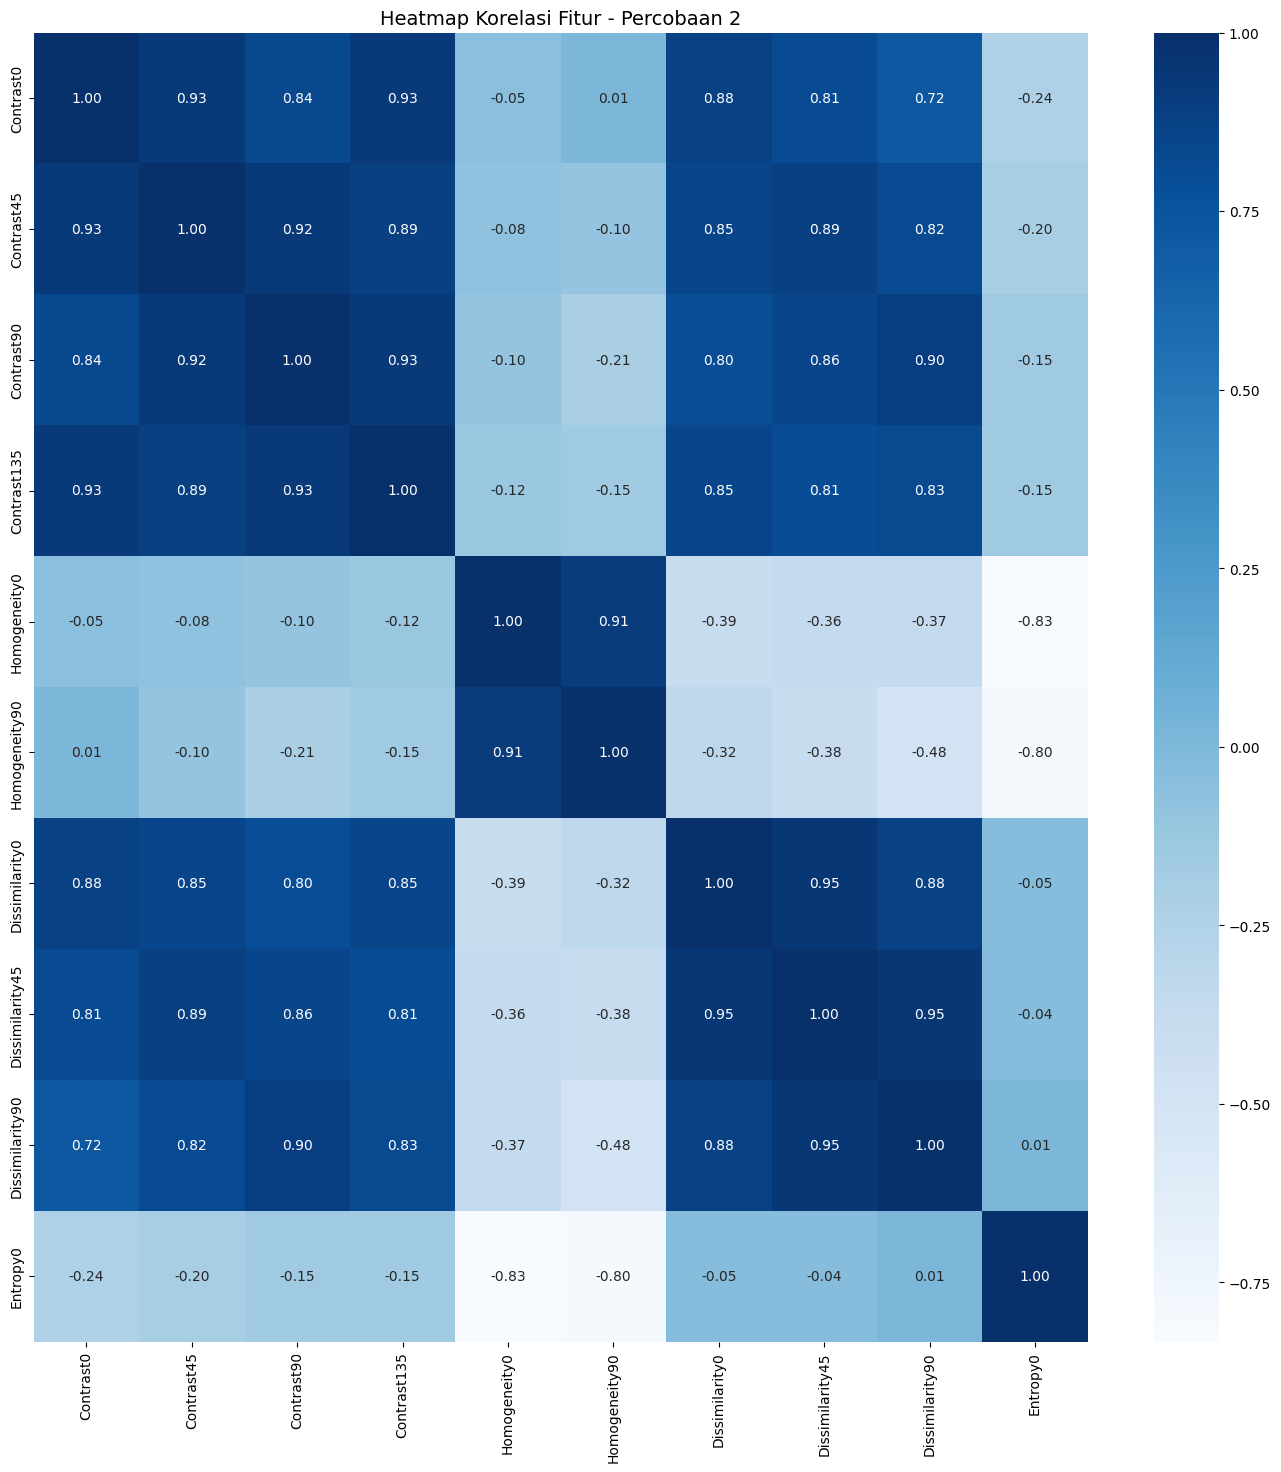

In [25]:
corr_matrix = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns = np.full((corr_matrix.shape[0],), True, dtype=bool)
for i in range(corr_matrix.shape[0]):
    for j in range(i+1, corr_matrix.shape[0]):
        if abs(corr_matrix.iloc[i,j]) >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f"Fitur sebelum seleksi : 28")
print(f"Fitur setelah seleksi : {len(select)}")
print(f"Fitur terpilih        : {list(select)}")

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Heatmap Korelasi Fitur - Percobaan 2', fontsize=14)
plt.show()

## Splitting Data

In [26]:
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.2 = 20% data untuk testing (train/test 80/20)
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(160, 10)
(40, 10)


## Pembagian Data Training dan Testing

Script di atas membagi dataset menjadi data training dan testing menggunakan `train_test_split` dengan rasio 80:20 — 80% data digunakan untuk melatih model dan 20% sisanya untuk pengujian. Parameter `random_state=42` digunakan untuk memastikan hasil pembagian yang konsisten dan dapat direproduksi. Setelah pembagian, dimensi dari masing-masing subset dicetak untuk memverifikasi jumlah sampel dan fitur yang terbagi dengan benar.

## Feature Normalization

berikut metode normalisasi yang bisa digunakan:
- Min-Max Scaling
- Standardization (Z-score)
- Robust Scaling
- MaxAbsScaler
- dll

berikut contoh menggunakan Standardization (Z-score):

In [27]:
mean_train = X_train.mean()
std_train  = X_train.std()

X_test  = (X_test  - mean_train) / std_train
X_train = (X_train - mean_train) / std_train

## Normalisasi Fitur dengan Z-score (Standardization)

Script di atas menormalisasi nilai fitur menggunakan metode Z-score agar setiap fitur berada pada skala yang sebanding. Rata-rata (`mean_train`) dan standar deviasi (`std_train`) dihitung hanya dari data training untuk menghindari kebocoran informasi dari data testing ke proses normalisasi. Rumus Z-score kemudian diterapkan pada data testing menggunakan parameter dari training, sebelum yang sama diterapkan pada data training itu sendiri. Pendekatan ini memastikan bahwa transformasi yang diterapkan pada data testing sepenuhnya didasarkan pada distribusi data training.

## Modeling

### Define Model

In [28]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

## Definisi Fungsi Evaluasi dan Inisialisasi Model

Script di atas mendefinisikan fungsi helper `generateClassificationReport` yang mencetak tiga informasi evaluasi sekaligus: classification report per kelas (precision, recall, F1-score), confusion matrix, dan akurasi keseluruhan. Selanjutnya, tiga model klasifikasi diinisialisasi dengan konfigurasi yang ditentukan — Random Forest dengan 5 pohon keputusan dan `random_state=42`, SVM dengan kernel RBF dan `random_state=42`, serta KNN dengan 5 tetangga terdekat.

### Train Random Forest Classifier

In [29]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
                     precision    recall  f1-score   support

Grape_black_rot_100       0.96      0.99      0.98        81
     daun_sehat_100       0.99      0.96      0.97        79

           accuracy                           0.97       160
          macro avg       0.98      0.97      0.97       160
       weighted avg       0.98      0.97      0.97       160

[[80  1]
 [ 3 76]]
Accuracy: 0.975

------Testing Set------
                     precision    recall  f1-score   support

Grape_black_rot_100       0.90      0.95      0.92        19
     daun_sehat_100       0.95      0.90      0.93        21

           accuracy                           0.93        40
          macro avg       0.93      0.93      0.92        40
       weighted avg       0.93      0.93      0.93        40

[[18  1]
 [ 2 19]]
Accuracy: 0.925


## Training dan Evaluasi Model Random Forest

Script di atas melatih model Random Forest menggunakan data training melalui `rf.fit(X_train, y_train)`. Setelah pelatihan, evaluasi dilakukan dua kali — pertama pada data training untuk mengukur seberapa baik model mempelajari pola data, dan kedua pada data testing untuk mengukur kemampuan generalisasi model terhadap data yang belum pernah dilihat sebelumnya. Setiap evaluasi mencetak classification report, confusion matrix, dan akurasi menggunakan fungsi `generateClassificationReport`.

### Train SVM Classifier

In [30]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
                     precision    recall  f1-score   support

Grape_black_rot_100       0.87      1.00      0.93        81
     daun_sehat_100       1.00      0.85      0.92        79

           accuracy                           0.93       160
          macro avg       0.94      0.92      0.92       160
       weighted avg       0.93      0.93      0.92       160

[[81  0]
 [12 67]]
Accuracy: 0.925

------Testing Set------
                     precision    recall  f1-score   support

Grape_black_rot_100       0.85      0.89      0.87        19
     daun_sehat_100       0.90      0.86      0.88        21

           accuracy                           0.88        40
          macro avg       0.88      0.88      0.87        40
       weighted avg       0.88      0.88      0.88        40

[[17  2]
 [ 3 18]]
Accuracy: 0.875


## Training dan Evaluasi Model SVM

Script di atas melatih model Support Vector Machine dengan kernel RBF menggunakan data training melalui `svm.fit(X_train, y_train)`. Evaluasi dilakukan pada data training dan data testing secara berurutan, masing-masing mencetak classification report, confusion matrix, dan akurasi melalui fungsi `generateClassificationReport`. Perbandingan performa antara data training dan testing digunakan untuk mendeteksi kemungkinan overfitting atau underfitting pada model.

### Train KNN Classifier

In [31]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)



------Training Set------
                     precision    recall  f1-score   support

Grape_black_rot_100       0.89      0.99      0.94        81
     daun_sehat_100       0.99      0.87      0.93        79

           accuracy                           0.93       160
          macro avg       0.94      0.93      0.93       160
       weighted avg       0.94      0.93      0.93       160

[[80  1]
 [10 69]]
Accuracy: 0.93125

------Testing Set------
                     precision    recall  f1-score   support

Grape_black_rot_100       0.86      0.95      0.90        19
     daun_sehat_100       0.95      0.86      0.90        21

           accuracy                           0.90        40
          macro avg       0.90      0.90      0.90        40
       weighted avg       0.90      0.90      0.90        40

[[18  1]
 [ 3 18]]
Accuracy: 0.9


## Training dan Evaluasi Model KNN

Script di atas melatih model K-Nearest Neighbors dengan 5 tetangga terdekat menggunakan data training melalui `knn.fit(X_train, y_train)`. Serupa dengan model sebelumnya, evaluasi dilakukan pada data training dan data testing secara berurutan, masing-masing mencetak classification report, confusion matrix, dan akurasi. Hasil evaluasi ini digunakan sebagai bahan perbandingan performa KNN terhadap Random Forest dan SVM.

## Evaluation With Confusion Matrix

## Visualisasi Confusion Matrix Ketiga Model

Script di bawah ini mendefinisikan fungsi `plot_confusion_matrix` yang membangun confusion matrix dari hasil prediksi model pada data testing, menampilkannya sebagai heatmap menggunakan `ConfusionMatrixDisplay` dengan colormap biru, dan memberi judul sesuai nama model. Fungsi tersebut kemudian dipanggil tiga kali secara berurutan untuk Random Forest, SVM, dan KNN, menghasilkan tiga plot confusion matrix yang dapat dibandingkan secara visual untuk melihat distribusi prediksi benar dan salah dari masing-masing model.

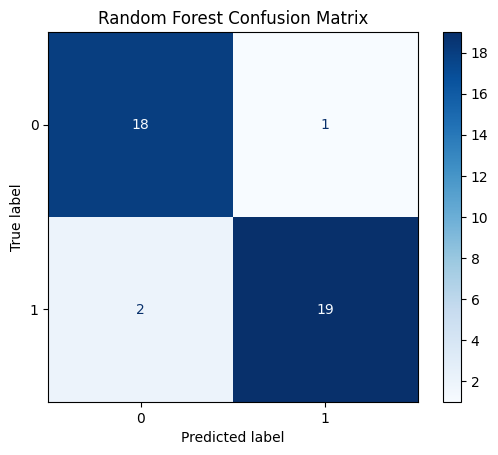

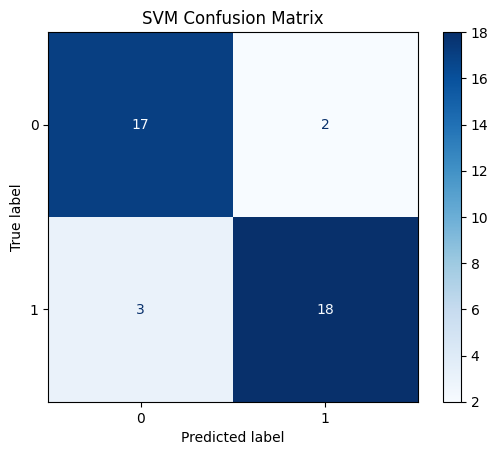

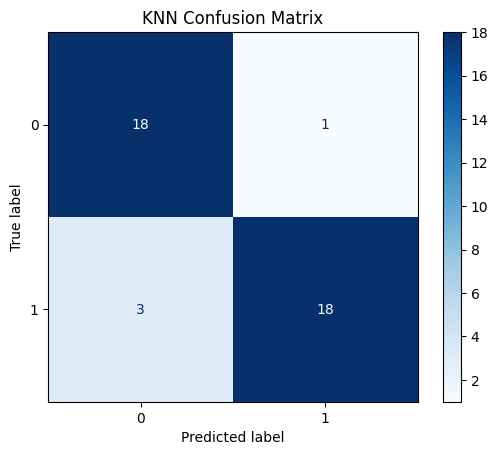

In [32]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")

In [33]:
# Simpan hasil perbandingan model
hasil_klasifikasi = {
    'Model'    : ['Random Forest', 'SVM', 'KNN'],
    'Accuracy_Train': [
        accuracy_score(y_train, rf.predict(X_train)),
        accuracy_score(y_train, svm.predict(X_train)),
        accuracy_score(y_train, knn.predict(X_train)),
    ],
    'Accuracy_Test': [
        accuracy_score(y_test, rf.predict(X_test)),
        accuracy_score(y_test, svm.predict(X_test)),
        accuracy_score(y_test, knn.predict(X_test)),
    ],
    'Precision': [
        precision_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        precision_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        precision_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'Recall': [
        recall_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        recall_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        recall_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'F1_Score': [
        f1_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        f1_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        f1_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
}
df_hasil = pd.DataFrame(hasil_klasifikasi)
df_hasil.to_csv('./klasifikasi/hasil_klasifikasi2.csv', index=False)
df_hasil

,Model,Accuracy_Train,Accuracy_Test,Precision,Recall,F1_Score
0,Random Forest,0.97500,0.925,0.926250,0.925,0.925047
1,SVM,0.92500,0.875,0.876250,0.875,0.875078
2,KNN,0.93125,0.900,0.904511,0.900,0.900000


## Penyusunan Tabel Perbandingan Model dan Ekspor ke CSV

Script di atas merangkum performa ketiga model klasifikasi ke dalam satu tabel perbandingan. Dictionary `hasil_klasifikasi` disusun dengan kolom yang mencakup nama model, akurasi training, akurasi testing, precision, recall, dan F1-score — di mana metrik precision, recall, dan F1-score dihitung menggunakan `average='weighted'` untuk memperhitungkan proporsi kelas. Dictionary dikonversi ke DataFrame, diekspor ke file CSV di path `./klasifikasi/hasil_klasifikasi2.csv`, dan ditampilkan sebagai tabel akhir untuk memudahkan perbandingan performa ketiga model secara langsung.